#Ciência de Dados: Análise de Dados Aplicada
##Trabalho final


###Aluno: Alan Nakamura Kageyama
###Ra: 2482053

##Bibliotecas

In [1]:
import urllib.request
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

import duckdb

##Fonte Principal: NYC Citywide Annualized Calendar Sales Update

###Pergunta
De que maneira a flutuação dos indicadores macroeconômicos e a densidade de criminalidade local influenciam a variação dos preços imobiliários nos diferentes distritos de Nova York?




###Hipoteses
Hipótese 1: Distritos com maior incidência de crimes graves apresentam uma desvalorização acentuada no preço por metro quadrado, sendo esta variável mais impactante em imóveis residenciais do que em comerciais.

Hipótese 2: A taxa de juros hipotecária é um preditor negativo do volume e preço dos imóveis.

Hipótese 3: Certos bairros apresentam uma "imunidade" maior a índices criminais elevados, mantendo preços estáveis devido à alta demanda, enquanto bairros periféricos são mais sensíveis tanto ao crime quanto à variação de juros.

Os dados dos anos de 2018-2021 são muito complicados por causa da pandemia. Por conta disso, decidi pegar os anos de 2022-2025.

###Carregando os dados

In [2]:
print("Iniciando o download do dataset Principal. Isso pode levar alguns segundos!")

filename = "nyc_sales_raw.csv"
url = "https://data.cityofnewyork.us/api/views/w2pb-icbu/rows.csv?accessType=DOWNLOAD"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset Principal. Isso pode levar alguns segundos!
nyc_sales_raw.csv baixado com sucesso! Tamanho: 133.68 MB
Download foi finalizado!


###Analisando os dados

In [3]:
df_nyc_sales = pd.read_csv('nyc_sales_raw.csv')
display(df_nyc_sales.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AS OF FINAL ROLL,BLOCK,LOT,EASE-MENT,BUILDING CLASS AS OF FINAL ROLL,ADDRESS,APARTMENT NUMBER,...,SALE PRICE,SALE DATE,Latitude,Longitude,Community Board,Council District,BIN,BBL,Census Tract 2020,Neighborhood Tabulation Area (NTA) (2020)
0,1,CHINATOWN,47 CONDO NON-BUSINESS STORAGE,4,172,1490,NaN,RS,"50 FRANKLIN STREET, S9B",S9B,...,1590000,06/21/2019,40.716951,-74.002500,101.0,1.0,1088222.0,1.001728e+09,31.0,MN0102
1,1,EAST VILLAGE,10 COOPS - ELEVATOR APARTMENTS,2,461,24,NaN,D4,"232 EAST 6TH STREET, 6D",NaN,...,515000,06/11/2019,40.727669,-73.989201,103.0,2.0,1006622.0,1.004610e+09,38.0,MN0303
2,1,FASHION,21 OFFICE BUILDINGS,4,779,23,NaN,O6,227 WEST 29TH STREET,NaN,...,0,05/03/2019,40.748263,-73.993857,105.0,3.0,1014284.0,1.007790e+09,95.0,MN0501
3,1,FASHION,13 CONDOS - ELEVATOR APARTMENTS,2,841,1044,NaN,R4,"16 WEST 40TH STREET, 26A",26A,...,5203258,03/11/2019,40.752505,-73.982574,105.0,4.0,1090404.0,1.008418e+09,84.0,MN0502
4,1,EAST VILLAGE,10 COOPS - ELEVATOR APARTMENTS,2,431,31,NaN,D4,"141 EAST THIRD STREET, 2E",NaN,...,975000,12/27/2019,40.723793,-73.985602,103.0,2.0,1005762.0,1.004310e+09,32.0,MN0303


In [4]:
display(df_nyc_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760914 entries, 0 to 760913
Data columns (total 29 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   BOROUGH                                    760914 non-null  int64  
 1   NEIGHBORHOOD                               760914 non-null  object 
 2   BUILDING CLASS CATEGORY                    760914 non-null  object 
 3   TAX CLASS AS OF FINAL ROLL                 756731 non-null  object 
 4   BLOCK                                      760914 non-null  int64  
 5   LOT                                        760914 non-null  int64  
 6   EASE-MENT                                  0 non-null       float64
 7   BUILDING CLASS AS OF FINAL ROLL            756731 non-null  object 
 8   ADDRESS                                    760914 non-null  object 
 9   APARTMENT NUMBER                           187994 non-null  object 
 10  ZIP CODE

None

In [5]:
display(df_nyc_sales.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
TAX CLASS AS OF FINAL ROLL,4183
BLOCK,0
LOT,0
EASE-MENT,760914
BUILDING CLASS AS OF FINAL ROLL,4183
ADDRESS,0
APARTMENT NUMBER,572920


###Limpeza de dados antes da integração

####Colunas para dropar
EASE-MENT: Coluna está completamente vazia.

APARTMENT NUMBER: Como estou analisando o impacto do bairro e indicadores macroeconômicos, o número exato do apartamento é um excesso de ruído.

BLOCK e LOT: Usarei o BOROUGH para integrar com os crimes. Deixar esses no modelo imagino que pode causar overfitting.

As outras são para questões administrativas, então podem ser retiradas.

In [6]:
columns_to_drop = ['EASE-MENT', 'APARTMENT NUMBER', 'BLOCK', 'LOT', 'Community Board',
                   'Council District', 'BIN', 'BBL', 'Census Tract 2020', 'Neighborhood Tabulation Area (NTA) (2020)',
                   'TAX CLASS AS OF FINAL ROLL', 'BUILDING CLASS AS OF FINAL ROLL']
df_nyc_sales = df_nyc_sales.drop(columns=columns_to_drop)

####Linhas para dropar, outliers e valores nulos
SALE_PRICE: Nula ou menor que 10.000, valores de 0 a 10.000 geralmente são trocas que não envolvem dinheiro ou heranças, e não vendas reais a preço de mercado.

SALE_DATE: Só é necessário o periodo de 2022-2025

ZIP_CODE: Nulo ou igual a 0, não é possivel integrar com a tabela de crimes nem descobrir se a escola vizinha é boa.

Latitude e Longitude são dados interessantes de ter, por isso vou eliminar as linhas com valores nulos.

Vendas duplicadas: Foram identificados algumas vendas duplicadas.

GROSS SQUARE FEET: Algumas linhas possuem valores muito baixos.

In [7]:
linhas_antes = df_nyc_sales.shape[0]

df_nyc_sales.dropna(subset=['SALE PRICE'], inplace=True)
df_nyc_sales = df_nyc_sales[df_nyc_sales['SALE PRICE'] > 10000]

df_nyc_sales.dropna(subset=['ZIP CODE'], inplace=True)
df_nyc_sales = df_nyc_sales[df_nyc_sales['ZIP CODE'] > 0]

df_nyc_sales.dropna(subset=['Latitude', 'Longitude'], inplace=True)

df_nyc_sales.drop_duplicates(inplace=True)

df_nyc_sales['SALE DATE'] = pd.to_datetime(df_nyc_sales['SALE DATE'])
df_nyc_sales = df_nyc_sales[df_nyc_sales['SALE DATE'].dt.year.between(2022, 2025)]

In [8]:
area_minima = 100

df_nyc_sales['GROSS SQUARE FEET'] = pd.to_numeric(
    df_nyc_sales['GROSS SQUARE FEET'].astype(str).str.replace(',', ''),
    errors='coerce'
)
df_nyc_sales.dropna(subset=['GROSS SQUARE FEET'], inplace=True)


df_nyc_sales = df_nyc_sales[
    (df_nyc_sales['GROSS SQUARE FEET'] >= area_minima)
].copy()

linhas_depois = df_nyc_sales.shape[0]
print(f"linhas removidas: {linhas_antes - linhas_depois} linhas descartadas.")

linhas removidas: 689738 linhas descartadas.


In [9]:
print(f"New shape of df_nyc_sales: {df_nyc_sales.shape}")

New shape of df_nyc_sales: (71176, 17)


In [10]:
display(df_nyc_sales.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


####Padronizando os dados que seram usados para a integração
Aqui o formato após a conversão é string (YYYY-MM)

Garantindo que o borough ta no formato certo

In [11]:
df_nyc_sales['SALE DATE'] = df_nyc_sales['SALE DATE'].dt.strftime('%Y-%m')
df_nyc_sales['BOROUGH'] = df_nyc_sales['BOROUGH'].astype(int)

In [12]:
if not os.path.exists('dados'):
    os.makedirs('dados')

df_nyc_sales.to_parquet('dados/nyc_vendas_limpo_sem_integracao.parquet', index=False)
print("Dataset de vendas limpo sem integração salvo com sucesso na pasta 'dados'!")

Dataset de vendas limpo sem integração salvo com sucesso na pasta 'dados'!


##Enriquecimento com Fontes Externa

###NYPD Complaint Data Historic

As vezes esses dados não baixam corretamente, se mantenha atento a isso.

####Carregando os dados

In [13]:
print("Iniciando o download do dataset NYPD Complaint Data Historic. Arquivo muito grande! Isso pode levar alguns minutos dependendo da sua internet...")

filename = "nypd_crimes_raw.csv"
url = "https://data.cityofnewyork.us/api/views/qgea-i56i/rows.csv?accessType=DOWNLOAD"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset NYPD Complaint Data Historic. Arquivo muito grande! Isso pode levar alguns minutos dependendo da sua internet...
nypd_crimes_raw.csv baixado com sucesso! Tamanho: 3270.30 MB
Download foi finalizado!


####Analisando os dados

In [14]:
con = duckdb.connect()

#####Reduzindo o Dataset para apenas o periodo de 2022-2025

In [15]:
print("Lendo o arquivo e filtrando apenas os anos de 2022 a 2025...")

query = """
    SELECT
        RPT_DT,
        BORO_NM,
        LAW_CAT_CD
    FROM read_csv_auto('nypd_crimes_raw.csv', all_varchar=true)
    WHERE
        CAST(str_split(RPT_DT, '/')[3] AS INTEGER) BETWEEN 2022 AND 2025
"""

df_crimes_filtrados = con.execute(query).df()

print(f"Sucesso! O dataset filtrado tem {df_crimes_filtrados.shape[0]} linhas.")

Lendo o arquivo e filtrando apenas os anos de 2022 a 2025...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sucesso! O dataset filtrado tem 2243782 linhas.


In [16]:
display(df_crimes_filtrados.head())

,RPT_DT,BORO_NM,LAW_CAT_CD
0,03/15/2022,BRONX,FELONY
1,03/18/2022,BRONX,FELONY
2,06/23/2022,BROOKLYN,FELONY
3,08/20/2022,BRONX,VIOLATION
4,03/08/2022,BRONX,VIOLATION


In [17]:
display(df_crimes_filtrados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243782 entries, 0 to 2243781
Data columns (total 3 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   RPT_DT      object
 1   BORO_NM     object
 2   LAW_CAT_CD  object
dtypes: object(3)
memory usage: 51.4+ MB


None

In [18]:
display(df_crimes_filtrados.isnull().sum())

,0
RPT_DT,0
BORO_NM,0
LAW_CAT_CD,0


####Limpando e padronizando os dados

In [19]:
#Data que ocorreu e o nome do distrito
df_crimes = df_crimes_filtrados.dropna(subset=['RPT_DT', 'BORO_NM']).copy()

dict_boroughs = {
    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5
}
df_crimes['borough_code'] = df_crimes['BORO_NM'].map(dict_boroughs)

df_crimes.dropna(subset=['borough_code'], inplace=True)

# Criando a chave Ano-Mês no formato YYYY-MM
df_crimes['RPT_DT'] = pd.to_datetime(df_crimes['RPT_DT'], errors='coerce')
df_crimes.dropna(subset=['RPT_DT'], inplace=True)
df_crimes['ano_mes'] = df_crimes['RPT_DT'].dt.strftime('%Y-%m')

#Contando quantos crimes graves e leves ocorreram por Bairro e por Mês
df_crimes_preparado = df_crimes.groupby(['borough_code', 'ano_mes']).apply(
    lambda x: pd.Series({
        'qtd_crimes_graves': (x['LAW_CAT_CD'] == 'FELONY').sum(),
        'qtd_crimes_leves': (x['LAW_CAT_CD'] == 'MISDEMEANOR').sum()
    })
).reset_index()

df_crimes_preparado['borough_code'] = df_crimes_preparado['borough_code'].astype(int)

print(f"Total de linhas agregadas: {df_crimes_preparado.shape[0]}")
display(df_crimes_preparado.head())

Total de linhas agregadas: 240


/tmp/ipykernel_1018/780189284.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_crimes_preparado = df_crimes.groupby(['borough_code', 'ano_mes']).apply(


,borough_code,ano_mes,qtd_crimes_graves,qtd_crimes_leves
0,1,2022-01,3262,4738
1,1,2022-02,3284,5343
2,1,2022-03,3647,6308
3,1,2022-04,3664,5956
4,1,2022-05,3971,6222


In [20]:
if not os.path.exists('dados'):
    os.makedirs('dados')

df_crimes_preparado.to_parquet('dados/crimes_agregados_mensal.parquet', index=False)
print("Arquivo salvo com sucesso na pasta 'dados'!")

Arquivo salvo com sucesso na pasta 'dados'!


###FRED - 30-Year Fixed Rate Mortgage Average

####Carregando os dados

In [21]:
print("Iniciando o download do dataset 30-Year Fixed Rate Mortgage Average.")

filename = "macro_economics_usa.csv"
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset 30-Year Fixed Rate Mortgage Average.
macro_economics_usa.csv baixado com sucesso! Tamanho: 0.04 MB
Download foi finalizado!


####Analisando os dados

In [22]:
df_juros = pd.read_csv('macro_economics_usa.csv')

display(df_juros.head())

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [23]:
df_juros['observation_date'] = pd.to_datetime(df_juros['observation_date'], errors='coerce')

# filtrando o dataset para os anos 2022-2025
df_juros = df_juros[df_juros['observation_date'].dt.year.between(2022, 2025)]

df_juros['ano_mes'] = df_juros['observation_date'].dt.strftime('%Y-%m')

display(df_juros.head())

,observation_date,MORTGAGE30US,ano_mes
2649,2022-01-06,3.22,2022-01
2650,2022-01-13,3.45,2022-01
2651,2022-01-20,3.56,2022-01
2652,2022-01-27,3.55,2022-01
2653,2022-02-03,3.55,2022-02


Padronização dos dados para integração

In [24]:
df_juros_preparado = df_juros.groupby('ano_mes')['MORTGAGE30US'].mean().reset_index()

df_juros_preparado.rename(columns={'MORTGAGE30US': 'media_juros_hipoteca'}, inplace=True)

display(df_juros_preparado.head())

,ano_mes,media_juros_hipoteca
0,2022-01,3.4450
1,2022-02,3.7625
2,2022-03,4.1720
3,2022-04,4.9825
4,2022-05,5.2300


###Integrando ao Dataset principal

A integração vai ser pelo codigo de distritos(borough) e mês/ano. Como no dataset principal, o distrito era identificado por id, foi necessário transformar o borough desse dataset em código.

In [25]:
# Bairro e o mês de venda com o bairro e o mês do crime
df_integrado_1 = pd.merge(
    df_nyc_sales,
    df_crimes_preparado,
    left_on=['BOROUGH', 'SALE DATE'],
    right_on=['borough_code', 'ano_mes'],
    how='left'
)

# 'borough_code' ficou duplicado
df_integrado_1.drop(columns=['borough_code'], errors='ignore', inplace=True)

df_dataset_final = pd.merge(
    df_integrado_1,
    df_juros_preparado,
    on='ano_mes',
    how='left'
)

print(f"Integração concluída! O formato final do dataset é: {df_dataset_final.shape}")

Integração concluída! O formato final do dataset é: (71176, 21)


In [26]:
display(df_dataset_final.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,ano_mes,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457.0,1.0,0.0,1.0,"1,668",1497.0,...,1,A1,615000,2024-12,40.853515,-73.896028,2024-12,3269,5063,6.7150
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,2073 BATHGATE AVENUE,10457.0,1.0,0.0,1.0,"1,933",1344.0,...,1,A1,425000,2024-06,40.850429,-73.895169,2024-06,3762,5154,6.9175
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,503 EAST 182 STREET,10457.0,1.0,0.0,1.0,"1,960",1705.0,...,1,A9,515000,2024-04,40.853532,-73.893581,2024-04,3398,4884,6.9925
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVE,10458.0,1.0,0.0,1.0,913,1248.0,...,1,A1,413000,2024-08,40.855847,-73.891755,2024-08,3948,5356,6.5000
4,2,BATHGATE,02 TWO FAMILY DWELLINGS,1538 WASHINGTON AVENUE,10457.0,2.0,0.0,2.0,"2,000",2400.0,...,1,B1,750000,2024-05,40.838296,-73.902962,2024-05,3777,5336,7.0600


In [27]:
display(df_dataset_final.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


In [28]:
df_dataset_final.to_parquet('dados/nyc_vendas_integrado_bruto.parquet', index=False)

##Limpeza de Dados

###Missing values

####Aplicando KNN-Imputer

In [29]:
from tqdm.notebook import tqdm #adição da barrinha de progresso

for col in ['GROSS SQUARE FEET', 'LAND SQUARE FEET']:
    df_dataset_final[col] = pd.to_numeric(df_dataset_final[col].astype(str).str.replace(',', ''), errors='coerce')

pedacos_imputados = []

#aqui fiz por bairro apenas para poder acompanhar o progresso
for bairro, df_bairro in tqdm(df_dataset_final.groupby('BOROUGH'), desc="Processando Bairros"):

    colunas_knn = ['SALE PRICE', 'Latitude', 'Longitude', 'YEAR BUILT', 'GROSS SQUARE FEET', 'LAND SQUARE FEET']
    df_num = df_bairro[colunas_knn].copy()

    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns, index=df_num.index)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    df_imputed_scaled = pd.DataFrame(imputer.fit_transform(df_scaled), columns=df_num.columns, index=df_num.index)

    df_imputed = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=df_num.columns, index=df_num.index)

    df_bairro_pronto = df_bairro.copy()
    for col in colunas_knn:
        df_bairro_pronto[col] = df_imputed[col]

    pedacos_imputados.append(df_bairro_pronto)

df_dataset_final = pd.concat(pedacos_imputados).sort_index()

print("Imputação com KNN concluída")

Processando Bairros:   0%|          | 0/5 [00:00<?, ?it/s]

Imputação com KNN concluída


In [30]:
display(df_dataset_final.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


In [31]:
display(df_dataset_final.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,ano_mes,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,615000.0,2024-12,40.853515,-73.896028,2024-12,3269,5063,6.7150
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,2073 BATHGATE AVENUE,10457.0,1.0,0.0,1.0,1933.0,1344.0,...,1,A1,425000.0,2024-06,40.850429,-73.895169,2024-06,3762,5154,6.9175
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,503 EAST 182 STREET,10457.0,1.0,0.0,1.0,1960.0,1705.0,...,1,A9,515000.0,2024-04,40.853532,-73.893581,2024-04,3398,4884,6.9925
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVE,10458.0,1.0,0.0,1.0,913.0,1248.0,...,1,A1,413000.0,2024-08,40.855847,-73.891755,2024-08,3948,5356,6.5000
4,2,BATHGATE,02 TWO FAMILY DWELLINGS,1538 WASHINGTON AVENUE,10457.0,2.0,0.0,2.0,2000.0,2400.0,...,1,B1,750000.0,2024-05,40.838296,-73.902962,2024-05,3777,5336,7.0600


###Inconsistências

In [32]:
df_dataset_final['TOTAL UNITS'] = df_dataset_final['RESIDENTIAL UNITS'] + df_dataset_final['COMMERCIAL UNITS']

###Padronização

In [33]:
df_dataset_final['ZIP CODE'] = df_dataset_final['ZIP CODE'].astype(int).astype(str)
df_dataset_final['NEIGHBORHOOD'] = df_dataset_final['NEIGHBORHOOD'].str.strip().str.upper()
df_dataset_final['BUILDING CLASS CATEGORY'] = df_dataset_final['BUILDING CLASS CATEGORY'].str.strip().str.upper()

if 'ano_mes' in df_dataset_final.columns:
    df_dataset_final.drop(columns=['ano_mes'], inplace=True)


##Dataset Final

In [34]:
display(df_dataset_final.head())
display(df_dataset_final.info())
df_dataset_final.to_parquet('dados/nyc_dados_finais_limpos.parquet', index=False)

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457,1.0,0.0,1.0,1668.0,1497.0,1899.0,1,A1,615000.0,2024-12,40.853515,-73.896028,3269,5063,6.7150
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,2073 BATHGATE AVENUE,10457,1.0,0.0,1.0,1933.0,1344.0,1899.0,1,A1,425000.0,2024-06,40.850429,-73.895169,3762,5154,6.9175
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,503 EAST 182 STREET,10457,1.0,0.0,1.0,1960.0,1705.0,1901.0,1,A9,515000.0,2024-04,40.853532,-73.893581,3398,4884,6.9925
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVE,10458,1.0,0.0,1.0,913.0,1248.0,1901.0,1,A1,413000.0,2024-08,40.855847,-73.891755,3948,5356,6.5000
4,2,BATHGATE,02 TWO FAMILY DWELLINGS,1538 WASHINGTON AVENUE,10457,2.0,0.0,2.0,2000.0,2400.0,1993.0,1,B1,750000.0,2024-05,40.838296,-73.902962,3777,5336,7.0600


<class 'pandas.core.frame.DataFrame'>
Index: 71176 entries, 0 to 71175
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BOROUGH                         71176 non-null  int64  
 1   NEIGHBORHOOD                    71176 non-null  object 
 2   BUILDING CLASS CATEGORY         71176 non-null  object 
 3   ADDRESS                         71176 non-null  object 
 4   ZIP CODE                        71176 non-null  object 
 5   RESIDENTIAL UNITS               71176 non-null  float64
 6   COMMERCIAL UNITS                71176 non-null  float64
 7   TOTAL UNITS                     71176 non-null  float64
 8   LAND SQUARE FEET                71176 non-null  float64
 9   GROSS SQUARE FEET               71176 non-null  float64
 10  YEAR BUILT                      71176 non-null  float64
 11  TAX CLASS AT TIME OF SALE       71176 non-null  int64  
 12  BUILDING CLASS AT TIME OF SALE  71176

None

O Dataset final ficou com 84968 linhas e 20 colunas. Para fins de comparação, outro dataset das vendas sem a integração também foi criado.

##Análise Exploratória e Consultas SQL

###Reestruturação Necessária


####Normalização da Data

In [35]:
df_dataset_final['SALE DATE'] = pd.to_datetime(df_dataset_final['SALE DATE'])
df_dataset_final['sale_year'] = df_dataset_final['SALE DATE'].dt.year
df_dataset_final['sale_month'] = df_dataset_final['SALE DATE'].dt.month
df_dataset_final['sale_day_of_week'] = df_dataset_final['SALE DATE'].dt.dayofweek


####Corrigindo alguns tipos numéricos

In [36]:
cols_para_int = ['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT']
for col in cols_para_int:
    df_dataset_final[col] = df_dataset_final[col].astype(int)

####Padronização de tipos

In [37]:
cols_categoricas = [
    'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
    'ZIP CODE', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE'
]
for col in cols_categoricas:
    df_dataset_final[col] = df_dataset_final[col].astype('category')

cols_para_remover = ['ADDRESS', 'SALE DATE']
df_dataset_final.drop(columns=cols_para_remover, inplace=True, errors='ignore')

####parquet final limpo 2.0

In [38]:
df_dataset_final.to_parquet('dados/nyc_dados_finais_limpos_v2.parquet', index=False)
print(df_dataset_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 71176 entries, 0 to 71175
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         71176 non-null  category
 1   NEIGHBORHOOD                    71176 non-null  category
 2   BUILDING CLASS CATEGORY         71176 non-null  category
 3   ZIP CODE                        71176 non-null  category
 4   RESIDENTIAL UNITS               71176 non-null  int64   
 5   COMMERCIAL UNITS                71176 non-null  int64   
 6   TOTAL UNITS                     71176 non-null  int64   
 7   LAND SQUARE FEET                71176 non-null  float64 
 8   GROSS SQUARE FEET               71176 non-null  float64 
 9   YEAR BUILT                      71176 non-null  int64   
 10  TAX CLASS AT TIME OF SALE       71176 non-null  category
 11  BUILDING CLASS AT TIME OF SALE  71176 non-null  category
 12  SALE PRICE             

###Consultas SQL

In [39]:
path_parquet = 'dados/nyc_dados_finais_limpos_v2.parquet'

####Análise Macro por Bairro

Analisa o preço por bairro e verefica o preço por metro quadrado

In [40]:
query1 = f"""
    SELECT
        BOROUGH,
        COUNT(*) as total_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio,
        ROUND(AVG("GROSS SQUARE FEET"), 2) as area_media,
        ROUND(AVG("SALE PRICE") / NULLIF(AVG("GROSS SQUARE FEET"), 0), 2) as preco_por_sqft,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves_mes
    FROM '{path_parquet}'
    GROUP BY BOROUGH
    ORDER BY preco_medio DESC
"""

df_analise_bairros = con.execute(query1).df()
display(df_analise_bairros)

,BOROUGH,total_vendas,preco_medio,area_media,preco_por_sqft,media_crimes_graves_mes
0,1,3242,15676500.96,73777.45,212.48,3794.0
1,3,21253,2189275.25,8476.86,258.26,4253.0
2,2,7635,1400859.03,9171.66,152.74,3428.0
3,4,26568,1250044.63,2525.30,495.01,3374.0
4,5,12478,787515.78,1955.50,402.72,534.0


/tmp/ipykernel_1018/3243275923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analise_bairros, x='BOROUGH', y='preco_por_sqft', palette='viridis')


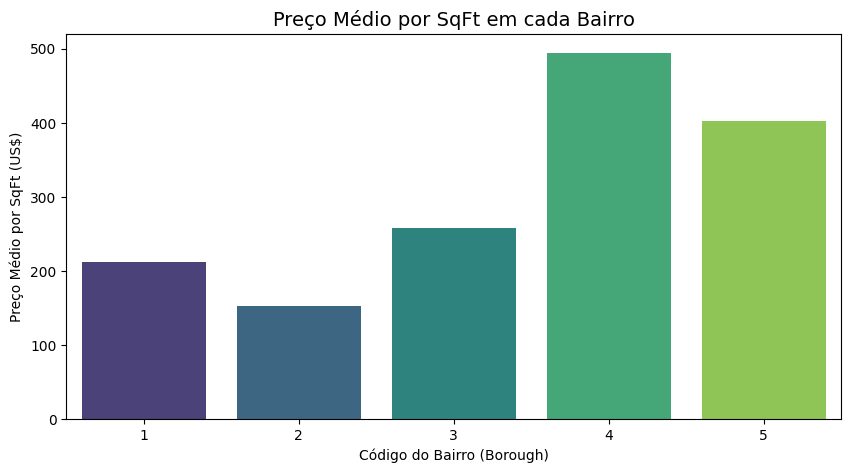

In [56]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_analise_bairros, x='BOROUGH', y='preco_por_sqft', palette='viridis')
plt.title('Preço Médio por SqFt em cada Bairro', fontsize=14)
plt.xlabel('Código do Bairro (Borough)')
plt.ylabel('Preço Médio por SqFt (US$)')
plt.show()

todo: alterar nome no grafico

    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5


####Impacto dos Juros



Analisando se a taxa de juros impacta de alguma forma o volume de vendas:

In [52]:
query2 = f"""
    SELECT
        media_juros_hipoteca,
        COUNT(*) as volume_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio
    FROM '{path_parquet}'
    GROUP BY media_juros_hipoteca
    ORDER BY media_juros_hipoteca ASC
"""

df_juros = con.execute(query2).df()
display(df_juros)

,media_juros_hipoteca,volume_vendas,preco_medio
0,3.4450,2371,1853616.25
1,3.7625,2298,1815367.26
2,4.1720,2673,4074125.38
3,4.9825,2244,2889943.53
4,5.2225,2456,1789793.45
5,5.2300,2604,2003268.35
6,5.4125,2390,1968927.88
7,5.5220,2844,2628599.75
8,6.1120,2248,2109690.59
9,6.1800,1954,2358721.77


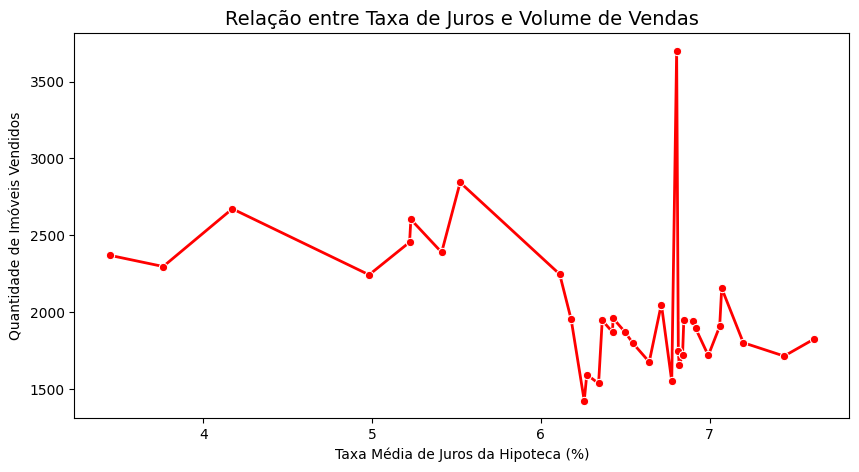

In [55]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_juros, x='media_juros_hipoteca', y='volume_vendas', marker='o', color='red', linewidth=2)
plt.title('Relação entre Taxa de Juros e Volume de Vendas', fontsize=14)
plt.xlabel('Taxa Média de Juros da Hipoteca (%)')
plt.ylabel('Quantidade de Imóveis Vendidos')
plt.show()

####Categorias de Imóveis vs Crimes

Verifica se os imóveis populares estão localizados em zonas com médias criminais mais altas em comparação aos imóveis de luxo.

In [65]:
query3 = f"""
    SELECT
        CASE
            WHEN "SALE PRICE" >= 2000000 THEN '1. Luxo (> $2M)'
            WHEN "SALE PRICE" < 500000 THEN '3. Popular (< $500k)'
            ELSE '2. Intermediário'
        END as categoria_imovel,
        COUNT(*) as qtd_vendas,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves,
        ROUND(AVG(qtd_crimes_leves), 0) as media_crimes_leves
    FROM '{path_parquet}'
    GROUP BY categoria_imovel
    ORDER BY categoria_imovel ASC
"""

df_luxo = con.execute(query3).df()
display(df_luxo)

,categoria_imovel,qtd_vendas,media_crimes_graves,media_crimes_leves
0,1. Luxo (> $2M),9359,3873.0,5908.0
1,2. Intermediário,54516,3103.0,4728.0
2,3. Popular (< $500k),7301,2706.0,4153.0


/tmp/ipykernel_1018/4277088676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_luxo, x='categoria_imovel', y='media_crimes_graves', palette='magma')


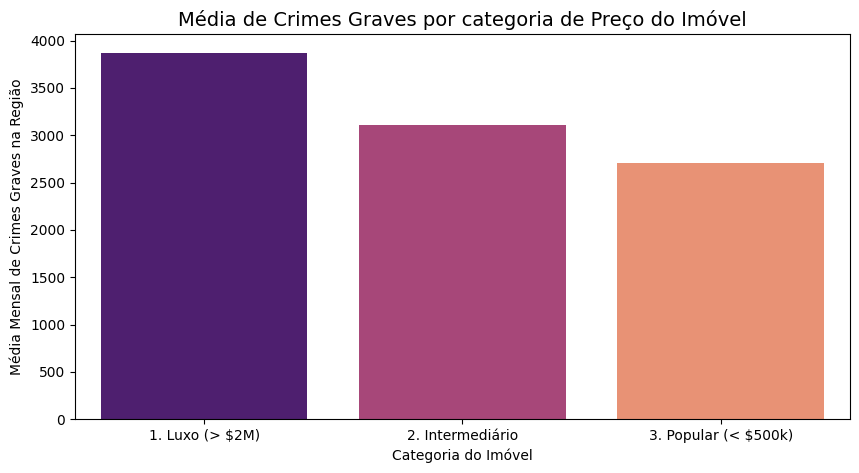

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_luxo, x='categoria_imovel', y='media_crimes_graves', palette='magma')
plt.title('Média de Crimes Graves por categoria de Preço do Imóvel', fontsize=14)
plt.xlabel('Categoria do Imóvel')
plt.ylabel('Média Mensal de Crimes Graves na Região')
plt.show()

Esse resultado pode ser explicado pela teoria da centralidade urbana e densidade demográfica de Nova York. Os imóveis de altíssimo padrão estão concentrados no núcleo central da cidade, regiões que atraem diariamente milhões de trabalhadores e turistas, além de concentrarem grande fluxo de capital. Essa extrema densidade de oportunidades eleva os números absolutos de registros criminais nas delegacias locais. Por outro lado, o mercado 'Popular' se localiza em zonas periféricas e predominantemente residenciais dos distritos externos, que possuem menor densidade populacional flutuante e, consequentemente, menor contagem absoluta de ocorrências.

####Sazonalidade de Vendas e Crimes

Verifica se há picos de vendas em algum mês e se há alguma correlação com o aumento da criminalidade nessas épocas.

In [46]:
query4 = f"""
    SELECT
        sale_month as mes,
        COUNT(*) as total_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio_venda,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves
    FROM '{path_parquet}'
    GROUP BY sale_month
    ORDER BY sale_month ASC
"""

df_sazonalidade = con.execute(query4).df()
display(df_sazonalidade)

,mes,total_vendas,preco_medio_venda,media_crimes_graves
0,1,5645,1833422.98,3023.0
1,2,5277,1784287.62,2844.0
2,3,6133,2792101.51,3081.0
3,4,5502,2412166.30,3028.0
4,5,6385,1841042.32,3304.0
5,6,6791,2451915.07,3265.0
6,7,6062,2063038.82,3390.0
7,8,6484,1734994.04,3390.0
8,9,6005,2024500.67,3235.0
9,10,5731,1855374.34,3270.0


/tmp/ipykernel_1018/104706544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sazonalidade, x='mes', y='total_vendas', palette='Blues_d')


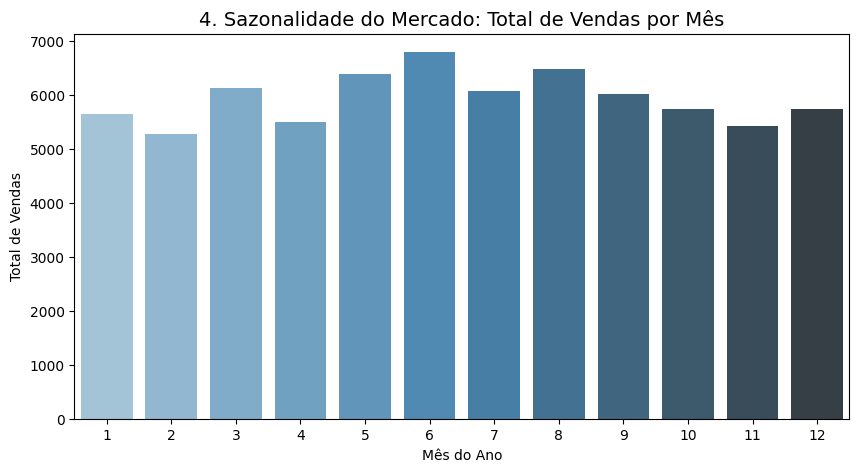

/tmp/ipykernel_1018/104706544.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sazonalidade, x='mes', y='media_crimes_graves', palette='Reds_d')


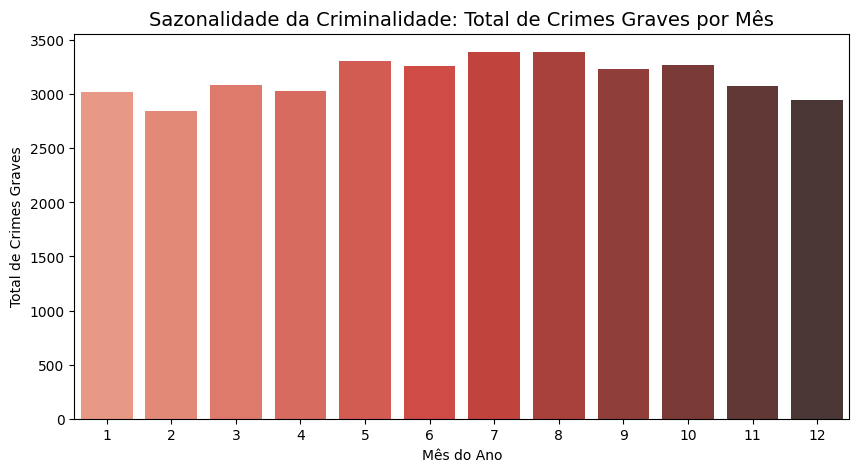

In [58]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sazonalidade, x='mes', y='total_vendas', palette='Blues_d')
plt.title('4. Sazonalidade do Mercado: Total de Vendas por Mês', fontsize=14)
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Vendas')
plt.show()
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sazonalidade, x='mes', y='media_crimes_graves', palette='Reds_d')
plt.title('Sazonalidade da Criminalidade: Total de Crimes Graves por Mês', fontsize=14)
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Crimes Graves')
plt.show()

Essa correlação evidencia o fator climático/sazonal como uma variável de confusão: meses mais quentes aumentam a circulação de capital e pessoas, aquecendo o mercado imobiliário, mas também aumentando a exposição a crimes. Para a etapa de Machine Learning, isso justifica a manutenção da variável 'Mês', para que o algoritmo não penalize erroneamente o preço de um imóvel vendido em Julho apenas por causa do pico natural de crimes daquela época.

####Micro-localização

Mostra ao avaliador os bairros específicos mais valorizados e com liquidez

In [48]:
query5 = f"""
    SELECT
        NEIGHBORHOOD,
        BOROUGH,
        COUNT(*) as volume_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio
    FROM '{path_parquet}'
    GROUP BY NEIGHBORHOOD, BOROUGH
    HAVING COUNT(*) > 100
    ORDER BY preco_medio DESC
    LIMIT 10
"""

df_top_bairros = con.execute(query5).df()
display(df_top_bairros)

,NEIGHBORHOOD,BOROUGH,volume_vendas,preco_medio
0,UPPER EAST SIDE (59-79),1,233,24775947.55
1,WILLIAMSBURG-NORTH,3,144,15468223.25
2,GREENWICH VILLAGE-WEST,1,177,13771093.95
3,CHELSEA,1,122,13574358.20
4,UPPER EAST SIDE (79-96),1,159,13508892.08
5,UPPER WEST SIDE (79-96),1,137,13204349.85
6,BROOKLYN HEIGHTS,3,130,8313811.18
7,WILLIAMSBURG-SOUTH,3,112,7912484.20
8,LONG ISLAND CITY,4,274,7695192.09
9,FORT GREENE,3,138,7498705.20


/tmp/ipykernel_1018/4006602141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_bairros, y='NEIGHBORHOOD', x='preco_medio', palette='rocket')


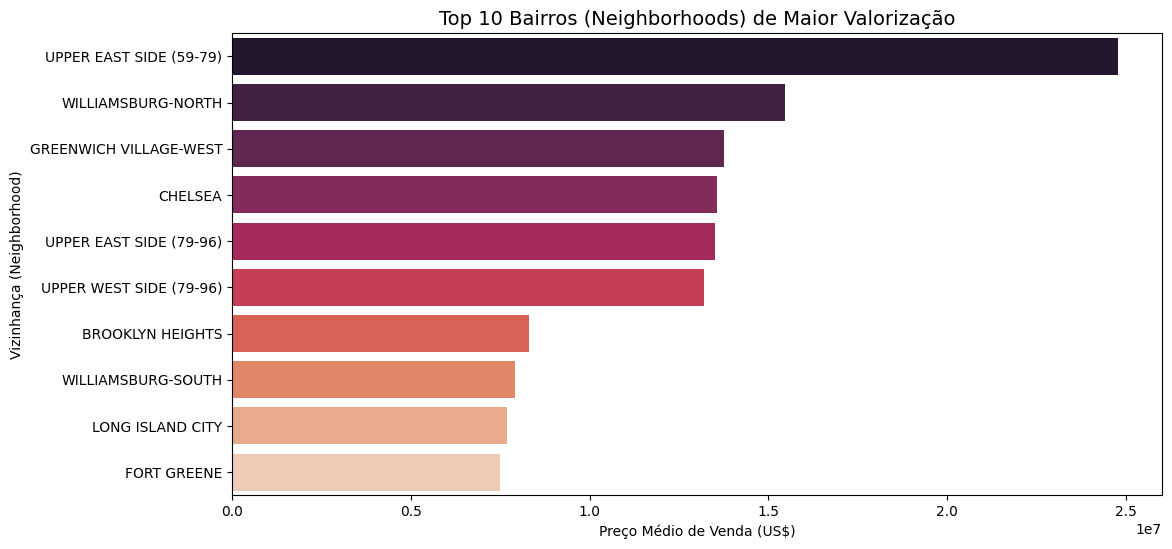

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_bairros, y='NEIGHBORHOOD', x='preco_medio', palette='rocket')
plt.title('Top 10 Bairros (Neighborhoods) de Maior Valorização', fontsize=14)
plt.xlabel('Preço Médio de Venda (US$)')
plt.ylabel('Vizinhança (Neighborhood)')
plt.show()

####Hipotese 1 - Segurança vs. Tipo de Propriedade

Para testar a Hipótese 1, realizamos uma agregação dos dados em formato de painel , agrupando as transações por Distrito, Mês de Venda e Tipo de Imóvel

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


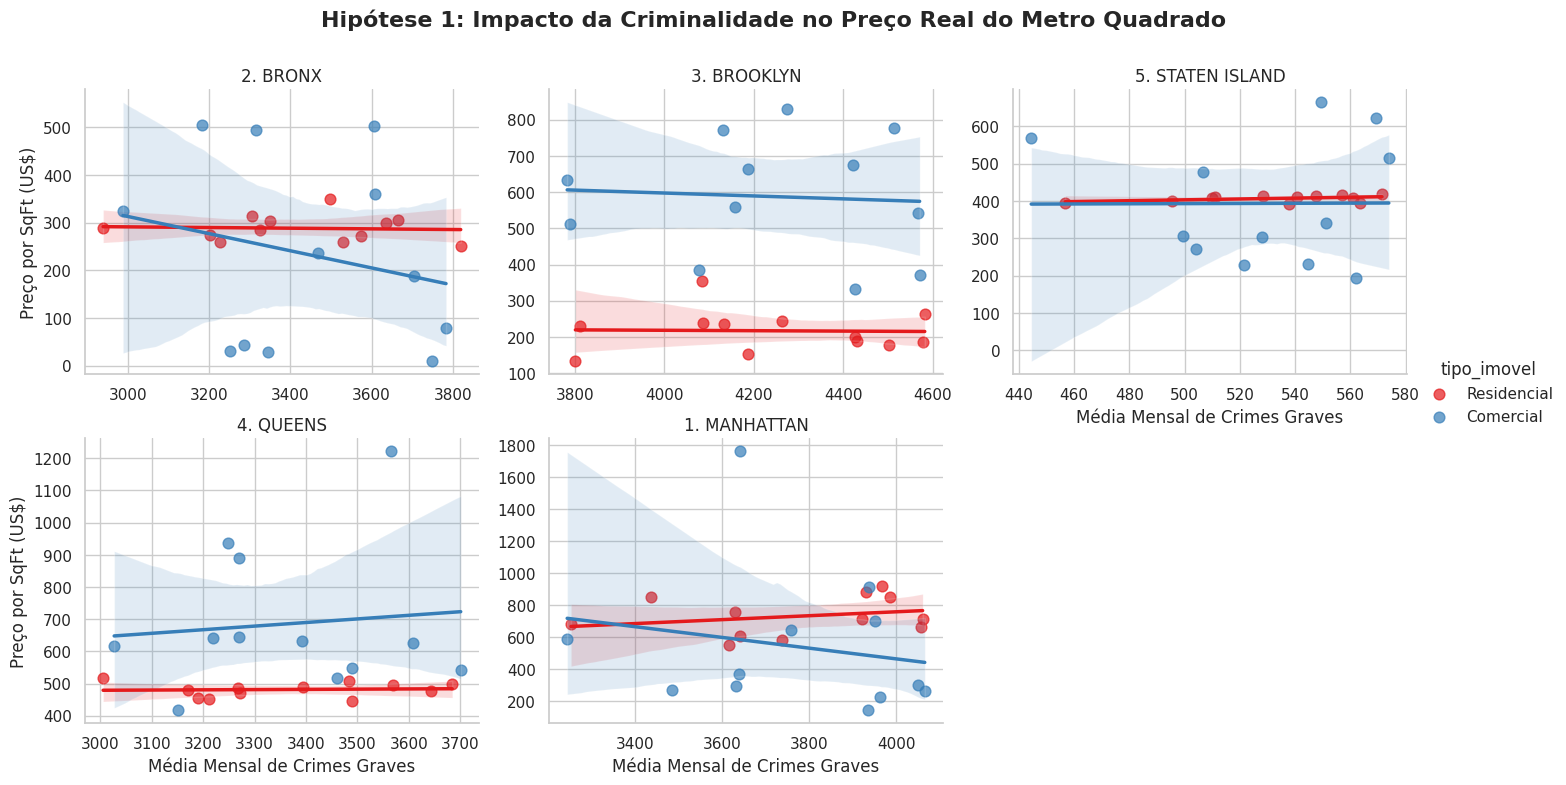

In [62]:
query_h1_otimizada = f"""
    SELECT
        CASE BOROUGH
            WHEN 1 THEN '1. MANHATTAN'
            WHEN 2 THEN '2. BRONX'
            WHEN 3 THEN '3. BROOKLYN'
            WHEN 4 THEN '4. QUEENS'
            WHEN 5 THEN '5. STATEN ISLAND'
        END AS nome_bairro,
        sale_month,
        CASE
            WHEN "RESIDENTIAL UNITS" > 0 AND "COMMERCIAL UNITS" = 0 THEN 'Residencial'
            WHEN "COMMERCIAL UNITS" > 0 AND "RESIDENTIAL UNITS" = 0 THEN 'Comercial'
            ELSE 'Misto'
        END AS tipo_imovel,
        AVG(qtd_crimes_graves) AS media_crimes_graves,
        SUM("SALE PRICE") / NULLIF(SUM("GROSS SQUARE FEET"), 0) AS preco_medio_sqft
    FROM '{path_parquet}'
    WHERE "GROSS SQUARE FEET" > 100
      AND "SALE PRICE" > 10000
    GROUP BY BOROUGH, sale_month, tipo_imovel
    HAVING tipo_imovel IN ('Residencial', 'Comercial')
"""

df_h1 = con.execute(query_h1_otimizada).df()

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=df_h1,
    x="media_crimes_graves",
    y="preco_medio_sqft",
    hue="tipo_imovel",
    col="nome_bairro",
    col_wrap=3,
    palette="Set1",
    height=4,
    aspect=1.2,
    sharey=False,
    sharex=False,
    scatter_kws={'alpha':0.7, 's': 60},
    line_kws={'linewidth':2.5}
)

g.set_axis_labels("Média Mensal de Crimes Graves", "Preço por SqFt (US$)")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Hipótese 1: Impacto da Criminalidade no Preço Real do Metro Quadrado', fontsize=16, fontweight='bold')

plt.show()

No Bronx e Manhattan a hipotese se comporta como esperado. O preço do comercial cai enquanto o residencial se mantém.

STATEN ISLAND é um distrito muito mais pacato, residencial e isolado. Pela baixa quantidade de crimes e comportamento de "subúrbio", o impacto visual é bem menor e as linhas são mais curtas.

In [66]:
linhas_tabela = []
for (bairro, tipo), grupo in df_h1.groupby(['nome_bairro', 'tipo_imovel']):
    if len(grupo) > 1:
        correlacao = grupo['media_crimes_graves'].corr(grupo['preco_medio_sqft'])
    else:
        correlacao = np.nan

    linhas_tabela.append({
        'Distrito (Borough)': bairro,
        'Tipo de Imóvel': tipo,
        'Média Crimes/Mês': round(grupo['media_crimes_graves'].mean(), 1),
        'Preço Médio/SqFt': f"${grupo['preco_medio_sqft'].mean():,.2f}",
        'Correlação (r)': round(correlacao, 3) if not np.isnan(correlacao) else "N/A"
    })

df_resumo_h1 = pd.DataFrame(linhas_tabela)
display(df_resumo_h1)

,Distrito (Borough),Tipo de Imóvel,Média Crimes/Mês,Preço Médio/SqFt,Correlação (r)
0,1. MANHATTAN,Comercial,3775.1,$537.83,-0.189
1,1. MANHATTAN,Residencial,3769.6,$728.56,0.260
2,2. BRONX,Comercial,3440.3,$233.78,-0.227
3,2. BRONX,Residencial,3422.5,$288.32,-0.061
4,3. BROOKLYN,Comercial,4241.3,$587.84,-0.066
5,3. BROOKLYN,Residencial,4240.3,$216.97,-0.026
6,4. QUEENS,Comercial,3366.8,$685.79,0.101
7,4. QUEENS,Residencial,3365.2,$481.51,0.065
8,5. STATEN ISLAND,Comercial,529.5,$393.73,0.005
9,5. STATEN ISLAND,Residencial,531.7,$406.92,0.422
